# Capstone Challenge: Global Fleet Reliability & Cost Analysis

Welcome to the ultimate Data Engine challenge. This task was engineered to test absolute mastery over the entire stack: **SQLAlchemy, pyodbc, Pandas, NumPy, Matplotlib, Seaborn, and OpenPyXL**.

### Scenario
You are the Lead Data Engineer for the global manufacturing fleet. Executive leadership requires a comprehensive diagnostic of all machinery to identify legacy assets (expired warranties) that are at high risk of catastrophic failure, and an aggregate performance overview across all global plants.

### The Mission:
1. **Extraction:** Establish an `SQLAlchemy` connection via `pyodbc` to `localhost\SQLEXPRESS/FactoryOperations`. Extract an `INNER JOIN` of `production_logs` and `machine_assets`.
2. **Transformation:** Use `Pandas` and `NumPy` to drop missing temperatures, categorize machinery into "Optimal", "Warning", or "Critical Overheating" via `np.where`, calculate a custom `Risk_Score`, and filter down to high-risk, expired-warranty assets.
3. **Aggregation:** Group by plant location to calculate total defects and mean temperatures.
4. **Visualization:** Use `Matplotlib` and `Seaborn` to create a dual-pane dashboard comparing temperature distributions via KDE plots and defect counts via Bar plots. Export as PNG.
5. **Multi-Sheet Export:** Export the aggregated summaries and the high-risk alert table into a single `Global_Fleet_Audit.xlsx` workbook on separate sheets using `OpenPyXL`.

In [1]:
# The complete environment is pre-loaded
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings

warnings.filterwarnings('ignore')

--- 
### Step 1: Extraction (SQLAlchemy & pyodbc)

In [2]:
print("[1/5] Executing SQLAlchemy Extraction...")
conn_uri = "mssql+pyodbc://@localhost\\SQLEXPRESS/FactoryOperations?driver=SQL+Server&Trusted_Connection=yes"
engine = create_engine(conn_uri)

query = """
SELECT 
    l.log_id, l.plant_location, l.machine_id, l.spindle_temp, l.defect_count, l.shift_date,
    a.manufacturer, a.procurement_year, a.warranty_status
FROM production_logs AS l
INNER JOIN machine_assets AS a 
    ON l.machine_id = a.asset_id
"""
df_raw = pd.read_sql(query, engine)
print(f"Extracted {len(df_raw)} records successfully.")

[1/5] Executing SQLAlchemy Extraction...
Extracted 5 records successfully.


--- 
### Step 2: Transformation (Pandas & NumPy)

In [3]:
print("[2/5] Applying Vectorized Transformations...")

# Clean: Drop missing temperature data
df_clean = df_raw.dropna(subset=['spindle_temp']).copy()

# Categorize: Nested np.where for Thermal Condition
df_clean['Thermal_Condition'] = np.where(
    df_clean['spindle_temp'] > 100.0, 'Critical Overheating',
    np.where(df_clean['spindle_temp'] > 80.0, 'Warning', 'Optimal')
)

# Feature Engineering: Calculate custom Risk Score
df_clean['Risk_Score'] = (df_clean['defect_count'] * 10) + (df_clean['spindle_temp'] * 0.5)

# Filter: High-risk, out-of-warranty assets
df_high_risk = df_clean[(df_clean['warranty_status'] == 'Expired') & (df_clean['Risk_Score'] > 100)]
print(f"Identified {len(df_high_risk)} high-risk legacy assets.")

[2/5] Applying Vectorized Transformations...
Identified 1 high-risk legacy assets.


--- 
### Step 3: Aggregation (Pandas)

In [4]:
print("[3/5] Aggregating Global Plant Metadata...")

# Group by plant location to calculate metrics
df_summary = df_clean.groupby('plant_location').agg({
    'defect_count': 'sum',
    'spindle_temp': 'mean'
}).reset_index()

df_summary.rename(columns={'defect_count': 'Total_Defects', 'spindle_temp': 'Average_Temp'}, inplace=True)
print(df_summary)

[3/5] Aggregating Global Plant Metadata...
  plant_location  Total_Defects  Average_Temp
0        Detroit              0          65.0
1         Munich             22          78.6
2          Tokyo              1         110.5


--- 
### Step 4: Advanced Visualization (Matplotlib & Seaborn)

[4/5] Rendering Executive Dashboard...


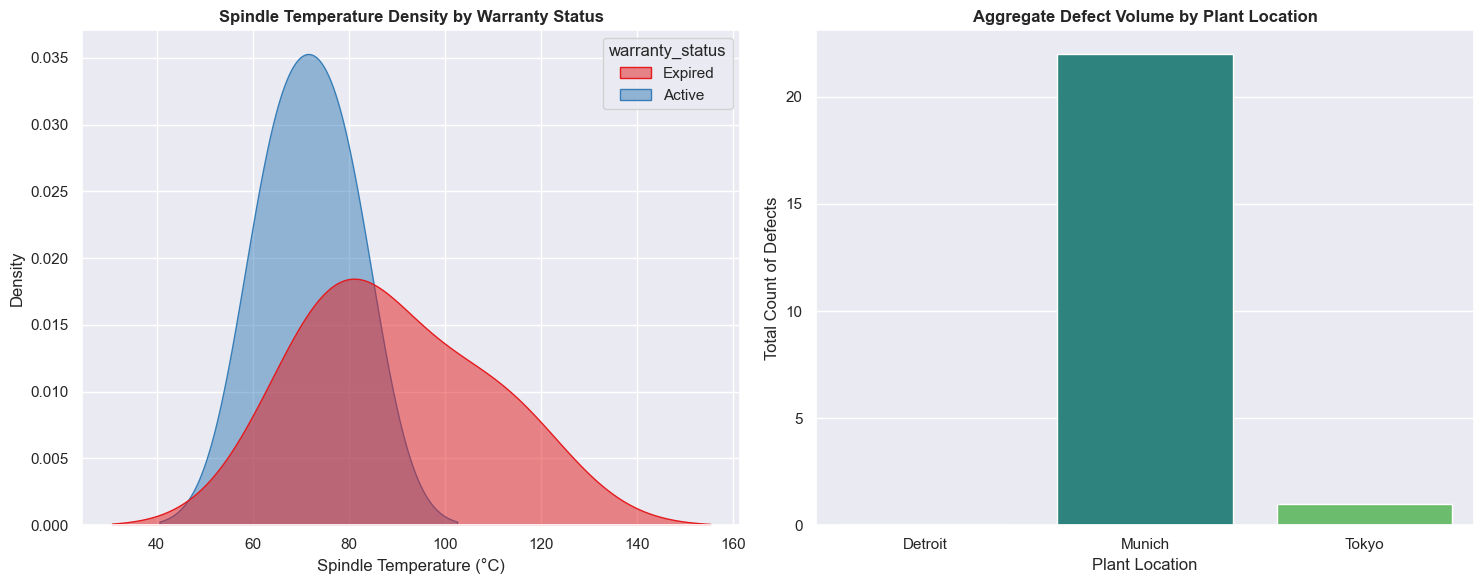

Dashboard saved as Executive_Dashboard.png


In [5]:
print("[4/5] Rendering Executive Dashboard...")

plt.figure(figsize=(15, 6))
sns.set_theme(style="darkgrid")

# Left Subplot: KDE Distribution of Temperatures
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_clean, x='spindle_temp', hue='warranty_status', fill=True, common_norm=False, alpha=0.5, palette='Set1')
plt.title('Spindle Temperature Density by Warranty Status', fontsize=12, fontweight='bold')
plt.xlabel('Spindle Temperature (°C)')
plt.ylabel('Density')

# Right Subplot: Bar Chart of Global Defects
plt.subplot(1, 2, 2)
sns.barplot(data=df_summary, x='plant_location', y='Total_Defects', palette='viridis')
plt.title('Aggregate Defect Volume by Plant Location', fontsize=12, fontweight='bold')
plt.xlabel('Plant Location')
plt.ylabel('Total Count of Defects')

plt.tight_layout()
plt.savefig('Executive_Dashboard.png', dpi=300)
plt.show()
print("Dashboard saved as Executive_Dashboard.png")

--- 
### Step 5: Multi-Sheet Export (Pandas & OpenPyXL)

In [6]:
print("[5/5] Executing Multi-Sheet Output Generation...")

# Utilizing pd.ExcelWriter to route DataFrames to independent sheets
output_path = 'Global_Fleet_Audit.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    df_summary.to_excel(writer, sheet_name='Plant_Summary', index=False)
    df_high_risk.to_excel(writer, sheet_name='High_Risk_Assets', index=False)

print(f"\n--- PIPELINE COMPLETE ---")
print(f"Data successfully processed and exported to {output_path}.")

[5/5] Executing Multi-Sheet Output Generation...

--- PIPELINE COMPLETE ---
Data successfully processed and exported to Global_Fleet_Audit.xlsx.
